# FastWoe Softmax WOE

Author: https://www.github.com/xRiskLab

`FastWoe(conditional=True)` measures each feature's weight inside the cell picked out by the features before it, by counting. With a few features that works; with more, the cells run thin and fall back to marginal weights.

**`SoftmaxWoe` is a generative classifier: per class, an autoregressive chain of penalized multinomial logistic regressions, fitted by maximum likelihood of the features given the class; its per-feature weights are Good's conditional weights of evidence under that model and sum exactly to the posterior log-odds.**

`SoftmaxWoe` replaces the counts with a small model per feature. Per class, each applicant's profile is a leaf in a tree with one level per feature (the hierarchical softmax of Goodfellow et al., 2016, §12.4.3.2). Each node is a softmax that predicts the bin of the next feature from the earlier bins, fitted once among bads and once among goods. The weight at a node is

$$W(\text{bad} : \text{bin}_i \mid \text{bin}_{<i}) = \log P(\text{bin}_i \mid \text{bin}_{<i}, \text{bad}) - \log P(\text{bin}_i \mid \text{bin}_{<i}, \text{good})$$

and the weights add up exactly to the profile's log-likelihood ratio.

The data here is synthetic, from a known generator, so every weight has a true value to compare against.

**Set `C` and `ORDER` in the next cell, then run all.** Small `C` shrinks every node toward the plain bin shares (the marginal scorecard). Large `C` lets each node follow the earlier bins freely. `ORDER` is the order the features are conditioned in.


In [1]:
C = 1.0  # inverse penalty strength: smaller = more shrinkage
N_TRAIN = 5000
SEED = 7

# Conditioning order: p(x1) * p(x2 | x1) * p(x3 | x1, x2). Change it here; the rest follows.
ORDER = ["delinq", "util", "inq"]
# ORDER = ["util", "delinq", "inq"]
# ORDER = ["inq", "delinq", "util"]
FEATURE_1, FEATURE_2, FEATURE_3 = ORDER

## The generator

Three binned features in a fixed order: delinquency, then utilization, then inquiries. In each class the bin of every feature depends on the earlier bins, and that dependence differs between bads and goods. This is what makes marginal WOE double count.

The generator always draws the features in this order (`GEN_ORDER`). The model's conditioning order is `ORDER`, set at the top, and need not match: the true conditional weights for any `ORDER` are computed from the generator's exact joint distribution.


In [2]:
import itertools
import warnings

import numpy as np
import pandas as pd

from fastwoe import FastWoe, SoftmaxWoe

pd.set_option("display.width", 60)
%config InlineBackend.figure_format = 'retina'

LEVELS = {
    "delinq": ["no", "yes"],
    "util": ["<30", "30-80", ">80"],
    "inq": ["0", "1-2", "3+"],
}
GEN_ORDER = list(LEVELS)  # the order the generator draws features in (fixed)
assert sorted(ORDER) == sorted(GEN_ORDER), "ORDER must list each feature once"
PRIOR_BAD = 0.10

rng = np.random.default_rng(SEED)
# true node scores: intercept per bin and class, plus one effect per earlier bin
TRUE = {}
for i, f in enumerate(GEN_ORDER):
    K = len(LEVELS[f])
    n_in = sum(len(LEVELS[g]) for g in GEN_ORDER[:i])
    for h in (1, 0):
        a = rng.normal(0, 0.8, K) + (np.linspace(-0.6, 0.6, K) if h else 0)
        B = rng.normal(0, 0.9, (n_in, K)) * (1.6 if h else 1.0)
        TRUE[(i, h)] = (a, B)


def softmax(z: np.ndarray) -> np.ndarray:
    """Softmax of each row."""
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


def onehot(df: pd.DataFrame, feats: list[str]) -> np.ndarray:
    """One-hot of the given features, every bin kept, in LEVELS order."""
    blocks = [np.eye(len(LEVELS[f]))[pd.Categorical(df[f], LEVELS[f]).codes] for f in feats]
    return np.hstack(blocks) if blocks else np.zeros((len(df), 0))


def gen_probs(i: int, h: int, df: pd.DataFrame) -> np.ndarray:
    """Generator's P(bin of GEN_ORDER[i] | earlier bins in GEN_ORDER, class h): rows x bins."""
    a, B = TRUE[(i, h)]
    return softmax(a + onehot(df, GEN_ORDER[:i]) @ B)


# every possible profile, with its exact probability in each class
PROFILES = pd.DataFrame(list(itertools.product(*LEVELS.values())), columns=GEN_ORDER)
JOINT = {}
for h in (1, 0):
    lik = np.ones(len(PROFILES))
    for i, f in enumerate(GEN_ORDER):
        codes = pd.Categorical(PROFILES[f], LEVELS[f]).codes
        lik *= gen_probs(i, h, PROFILES)[np.arange(len(PROFILES)), codes]
    JOINT[h] = PROFILES.assign(p=lik)


def true_cond(f: str, h: int, df: pd.DataFrame, order: list[str] | None = None) -> np.ndarray:
    """True P(row's bin of f | its bins of the features before f in order, class h)."""
    order = ORDER if order is None else order
    before = order[: order.index(f)]
    joint = JOINT[h]
    num = joint.groupby(before + [f], as_index=False).p.sum()
    p = df[before + [f]].merge(num, how="left", on=before + [f]).p.to_numpy()
    if before:
        den = joint.groupby(before, as_index=False).p.sum()
        p = p / df[before].merge(den, how="left", on=before).p.to_numpy()
    return p


def true_weights(df: pd.DataFrame, order: list[str] | None = None) -> np.ndarray:
    """True conditional weight of every feature for every row, in ORDER (or the given order)."""
    order = ORDER if order is None else order
    return np.column_stack(
        [np.log(true_cond(f, 1, df, order) / true_cond(f, 0, df, order)) for f in order]
    )


def sample(n: int) -> pd.DataFrame:
    """Draw n applicants from the generator."""
    y = (rng.random(n) < PRIOR_BAD).astype(int)
    df = pd.DataFrame({"y": y})
    for i, f in enumerate(GEN_ORDER):
        df[f] = ""
        for h in (1, 0):
            m = (df.y == h).to_numpy()
            p = gen_probs(i, h, df[m])
            k = (p.cumsum(1) > rng.random((m.sum(), 1))).argmax(1)
            df.loc[m, f] = np.array(LEVELS[f])[k]
    return df[GEN_ORDER + ["y"]]


train, test = sample(N_TRAIN), sample(20_000)
print(f"train {len(train)}: {train.y.sum()} bad, {(1 - train.y).sum()} good")
print(f"{len(PROFILES)} possible profiles; conditioning order: {' > '.join(ORDER)}")
train.head()

train 5000: 501 bad, 4499 good
18 possible profiles; conditioning order: delinq > util > inq


,delinq,util,inq,y
0,no,30-80,1-2,0
1,no,30-80,1-2,0
2,no,>80,0,0
3,no,30-80,1-2,0
4,no,>80,1-2,0


## What the method does, in plain words

Take the bads and the goods separately and describe how each group looks, one feature at a time. At every step, look only at the people who match the applicant so far. In the default `ORDER`:

1. **Delinquency.** What share of bads, and what share of goods, have the applicant's delinquency bin?
2. **Utilization, among people with that delinquency bin.** What share of those bads, and of those goods, have the applicant's utilization bin?
3. **Inquiries, among people with that delinquency and utilization.** Same question.

Each step's evidence is the log of the two shares' ratio, the step's weight. If a bin is three times as common among bads as among goods, the weight is log 3 = +1.1; if it is three times as common among goods, −1.1. The prior log-odds plus the weights is the applicant's log-odds of being bad. Because every step looks only inside the group the earlier features picked out, evidence two features share is counted once (this is Good's chain rule, the same as `FastWoe(conditional=True)`).

**Where the softmax comes in.** Steps 2 and 3 need shares inside small groups, and counting is unreliable there: some groups hold only a handful of bads. So each step's shares are _predicted_ instead, by a logistic regression that takes the earlier bins as inputs, fitted once among bads and once among goods. A small group borrows strength from the others. "Softmax" is the formula that turns the regression's scores into shares that add up to 100%.


## In plain scikit-learn

Before using `SoftmaxWoe`, here is the whole method by hand, in the order set by `ORDER`. Note what each model's target is: **never `y`**. The target `y` only splits the training rows into bads and goods. Within each group, every model predicts a _feature's bin_ from the bins of the features before it:

| Node | Target            | Inputs                              | Fitted on               |
| ---- | ----------------- | ----------------------------------- | ----------------------- |
| 0    | `FEATURE_1`'s bin | nothing: just the share of each bin | bads; separately, goods |
| 1    | `FEATURE_2`'s bin | `FEATURE_1`                         | bads; separately, goods |
| 2    | `FEATURE_3`'s bin | `FEATURE_1` and `FEATURE_2`         | bads; separately, goods |

With the default `ORDER` (delinq, util, inq), `node_1_bad` answers _"for a bad applicant with this delinquency, how likely is each utilization bin?"_, and `node_1_good` the same for goods.


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

bads_df, goods_df = train[train.y == 1], train[train.y == 0]

# p(x1) * p(x2 | x1) * p(x3 | x1, x2), with FEATURE_1, FEATURE_2, FEATURE_3 from ORDER
print(f"order: {FEATURE_1} > {FEATURE_2} > {FEATURE_3}")


def shares(column: pd.Series) -> pd.Series:
    """Share of each bin, with 0.5 added to every count so no bin is exactly 0."""
    counts = column.value_counts().reindex(LEVELS[column.name], fill_value=0) + 0.5
    return counts / counts.sum()


def node_penalty(target: pd.Series) -> float:
    """The penalty for a node: 2C when its target has two bins, as SoftmaxWoe does.

    With two bins scikit-learn fits one logit instead of a coefficient row per bin,
    which the same C would penalize twice as hard as a softmax with three or more.
    """
    return 2 * C if target.nunique() == 2 else C


# -------------------------------------------------------------------------------
# node 0, FEATURE_1: no model, just the share of each bin
# -------------------------------------------------------------------------------
node_0_bad, node_0_good = shares(bads_df[FEATURE_1]), shares(goods_df[FEATURE_1])
print(f"\n{FEATURE_1} bad shares:\n{node_0_bad}")
print(f"{FEATURE_1} good shares:\n{node_0_good}")


# -------------------------------------------------------------------------------
# node 1, FEATURE_2: target is FEATURE_2's bin, input is FEATURE_1
# -------------------------------------------------------------------------------
node_1_ohe_bads, node_1_ohe_goods = onehot(bads_df, [FEATURE_1]), onehot(goods_df, [FEATURE_1])
node_1_target, node_1_target_goods = bads_df[FEATURE_2], goods_df[FEATURE_2]

print(f"\nShape of node 1 one-hot encoded bads: {node_1_ohe_bads.shape}")
print(f"Shape of node 1 one-hot encoded goods: {node_1_ohe_goods.shape}")

node_1_bad = LogisticRegression(C=node_penalty(node_1_target), max_iter=5000).fit(
    node_1_ohe_bads, node_1_target
)
node_1_good = LogisticRegression(C=node_penalty(node_1_target_goods), max_iter=5000).fit(
    node_1_ohe_goods, node_1_target_goods
)

print(f"\n{FEATURE_2} bad model coefficients: \n{node_1_bad.coef_}")
print(f"\n{FEATURE_2} good model coefficients: \n{node_1_good.coef_}")


# -------------------------------------------------------------------------------
# node 2, FEATURE_3: target is FEATURE_3's bin, inputs are FEATURE_1 and FEATURE_2
# -------------------------------------------------------------------------------
node_2_ohe_bads, node_2_ohe_goods = (
    onehot(bads_df, [FEATURE_1, FEATURE_2]),
    onehot(goods_df, [FEATURE_1, FEATURE_2]),
)
node_2_target, node_2_target_goods = bads_df[FEATURE_3], goods_df[FEATURE_3]

print(f"\nShape of node 2 one-hot encoded bads: {node_2_ohe_bads.shape}")
print(f"Shape of node 2 one-hot encoded goods: {node_2_ohe_goods.shape}")

node_2_bad = LogisticRegression(C=node_penalty(node_2_target), max_iter=5000).fit(
    node_2_ohe_bads, node_2_target
)
node_2_good = LogisticRegression(C=node_penalty(node_2_target_goods), max_iter=5000).fit(
    node_2_ohe_goods, node_2_target_goods
)

print(f"\n{FEATURE_3} bad model coefficients: \n{node_2_bad.coef_}")
print(f"\n{FEATURE_3} good model coefficients: \n{node_2_good.coef_}")

order: delinq > util > inq

delinq bad shares:
delinq
no     0.23008
yes    0.76992
Name: count, dtype: float64
delinq good shares:
delinq
no     0.609889
yes    0.390111
Name: count, dtype: float64

Shape of node 1 one-hot encoded bads: (501, 2)
Shape of node 1 one-hot encoded goods: (4499, 2)

util bad model coefficients: 
[[-0.25253952  0.25287973]
 [ 0.59480009 -0.59496368]
 [-0.34226058  0.34208395]]

util good model coefficients: 
[[ 0.65974493 -0.58359478]
 [-0.19067727 -0.39464417]
 [-0.46906765  0.97823895]]

Shape of node 2 one-hot encoded bads: (501, 5)
Shape of node 2 one-hot encoded goods: (4499, 5)

inq bad model coefficients: 
[[ 0.22004942 -0.22012891 -0.39237018  0.36644201  0.02584868]
 [-1.32791614  1.32702087  0.17858518 -0.1112193  -0.06826115]
 [ 1.10786672 -1.10689196  0.213785   -0.25522271  0.04241247]]

inq good model coefficients: 
[[-0.27372462  0.28025327  0.69725326 -0.46362104 -0.22710356]
 [ 0.58882785 -0.58231449 -0.02136961  0.42865192 -0.40076895]
 [-

For every applicant, ask both models at each node how likely the applicant's _actual_ bin is. The weight is the log of the ratio, and the score is the prior log-odds plus the weights, a plain row sum. That is Bayes' rule one feature at a time: adding the logs multiplies the ratios.

$$\text{odds}(\text{bad} \mid \text{applicant}) = \text{prior odds} \times \prod_i \frac{P(\text{bin}_i \mid \text{earlier bins}, \text{bad})}{P(\text{bin}_i \mid \text{earlier bins}, \text{good})}$$


In [4]:
def own_bin_prob(model: LogisticRegression, X: np.ndarray, observed: pd.Series) -> np.ndarray:
    """Each row's predicted probability of the bin it actually has."""
    columns = pd.Index(model.classes_).get_indexer(observed)
    return model.predict_proba(X)[np.arange(len(X)), columns]


# -------------------------------------------------------------------------------
# P(the row's own bin | earlier bins, bad) and the same among goods, per node
# -------------------------------------------------------------------------------
p_bad_df = pd.DataFrame(
    {
        FEATURE_1: node_0_bad[test[FEATURE_1]].to_numpy(),
        FEATURE_2: own_bin_prob(node_1_bad, onehot(test, [FEATURE_1]), test[FEATURE_2]),
        FEATURE_3: own_bin_prob(node_2_bad, onehot(test, [FEATURE_1, FEATURE_2]), test[FEATURE_3]),
    },
    index=test.index,
)
p_good_df = pd.DataFrame(
    {
        FEATURE_1: node_0_good[test[FEATURE_1]].to_numpy(),
        FEATURE_2: own_bin_prob(node_1_good, onehot(test, [FEATURE_1]), test[FEATURE_2]),
        FEATURE_3: own_bin_prob(node_2_good, onehot(test, [FEATURE_1, FEATURE_2]), test[FEATURE_3]),
    },
    index=test.index,
)

weights = np.log(p_bad_df / p_good_df)  # one weight per feature and row
manual_prior = np.log(len(bads_df) / len(goods_df))
manual_score = manual_prior + weights.sum(axis=1)  # it's just a sum
manual_p_bad = 1 / (1 + np.exp(-manual_score))

print(f"prior log-odds {manual_prior:+.3f}")
print(f"mean predicted P(bad) {manual_p_bad.mean():.4f}, observed bad rate {test.y.mean():.4f}")
weights.assign(score=manual_score, p_bad=manual_p_bad).head().round(3)


# -------------------------------------------------------------------------------
# Measure log loss
# -------------------------------------------------------------------------------
manual_log_loss = log_loss(test.y, manual_p_bad)
print(f"Manual log loss: {manual_log_loss:.4f}")

prior log-odds -2.195
mean predicted P(bad) 0.0973, observed bad rate 0.0985
Manual log loss: 0.2022


One applicant, row by row through the nodes:


In [5]:
a = test.iloc[0]
print(", ".join(f"{f}={a[f]}" for f in ORDER))
print(f"{'step':8}{'bin':>6}{'P|bad':>8}{'P|good':>8}{'weight':>9}{'running':>9}")
running = manual_prior
print(f"{'prior':8}{'':>6}{'':>8}{'':>8}{'':>9}{running:+9.3f}")
for f in ORDER:
    running += weights[f].iloc[0]
    print(
        f"{f:8}{a[f]:>6}{p_bad_df[f].iloc[0]:8.3f}{p_good_df[f].iloc[0]:8.3f}"
        f"{weights[f].iloc[0]:+9.3f}{running:+9.3f}"
    )
print(f"\nP(bad) = {manual_p_bad.iloc[0]:.4f}")

delinq=no, util=<30, inq=1-2
step       bin   P|bad  P|good   weight  running
prior                                     -2.195
delinq      no   0.230   0.610   -0.975   -3.170
util       <30   0.647   0.127   +1.629   -1.540
inq        1-2   0.022   0.468   -3.067   -4.607

P(bad) = 0.0099


## Fit SoftmaxWoe

`SoftmaxWoe` does exactly the above for any number of features, and also bins numerical features. One node model per feature and class. The first node has no earlier bins, so it is the bin shares (with a 0.5 pseudo-count). Earlier bins enter one-hot with every bin kept, so the penalty treats all bins alike. `order` fixes the conditioning order; unlike counted conditional WOE, it changes the score as well as the attribution.


In [6]:
model = SoftmaxWoe(order=ORDER, C=C).fit(train[ORDER], train.y)
prior = model.prior_log_odds_
print(f"C = {C}, prior log-odds {prior:+.3f}")
score = prior + model.transform(test[ORDER]).sum(axis=1)
print(
    f"largest difference from the plain scikit-learn scores: {(score - manual_score).abs().max():.1e}"
)
model.transform(test[ORDER].head())

C = 1.0, prior log-odds -2.195
largest difference from the plain scikit-learn scores: 2.9e-13


,delinq,util,inq
0,-0.974851,1.629423,-3.066557
1,0.679855,-0.308553,0.851306
2,-0.974851,-1.875120,-3.840206
3,-0.974851,-1.875120,-3.840206
4,-0.974851,-1.875120,-3.840206


## The bins at each node

For every path of earlier bins: the fitted P(bin | bad) and P(bin | good) from `node_proba`, the weight W, the true weight, and how many training bads and goods sit on that path. Re-run with another `C` to watch the weights move.


In [7]:
def show_node(f: str) -> None:
    """Print the fitted and true weights of feature f for every path of earlier bins."""
    i = ORDER.index(f)
    print(f"node {i}: {f}")
    for path in itertools.product(*[LEVELS[g] for g in ORDER[:i]]):
        given = dict(zip(ORDER[:i], path))
        rows = pd.DataFrame([given] * len(LEVELS[f]), columns=ORDER[:i])
        rows[f] = LEVELS[f]
        p = model.node_proba(rows, f)
        t1, t0 = true_cond(f, 1, rows), true_cond(f, 0, rows)
        on = (train[ORDER[:i]] == pd.Series(given)).all(1) if i else train.y >= 0
        nb, ng = int(train.y[on].sum()), int((1 - train.y[on]).sum())
        label = ", ".join(f"{g}={v}" for g, v in given.items()) or "(nothing yet)"
        print(f"given {label}   [{nb} bad, {ng} good]")
        out = pd.DataFrame(
            {
                "P|bad": p.p_event.to_numpy(),
                "P|good": p.p_nonevent.to_numpy(),
                "W": np.log(p.p_event / p.p_nonevent).to_numpy(),
                "true W": np.log(t1 / t0),
            },
            index=LEVELS[f],
        )
        print(out.round(3).to_string(), "\n")


for f in ORDER:
    show_node(f)

node 0: delinq
given (nothing yet)   [501 bad, 4499 good]
     P|bad  P|good      W  true W
no    0.23    0.61 -0.975  -1.174
yes   0.77    0.39  0.680   0.757 

node 1: util
given delinq=no   [115 bad, 2744 good]
       P|bad  P|good      W  true W
<30    0.647   0.127  1.629   1.729
30-80  0.089   0.581 -1.875  -2.258
>80    0.264   0.292 -0.101  -0.282 

given delinq=yes   [386 bad, 1755 good]
       P|bad  P|good      W  true W
<30    0.227   0.068  1.199   0.881
30-80  0.170   0.111  0.429   0.636
>80    0.603   0.821 -0.309  -0.310 

node 2: inq
given delinq=no, util=<30   [75 bad, 348 good]
     P|bad  P|good      W  true W
0    0.207   0.527 -0.937  -0.910
1-2  0.022   0.468 -3.067  -3.158
3+   0.772   0.005  5.119   5.855 

given delinq=no, util=30-80   [10 bad, 1596 good]
     P|bad  P|good      W  true W
0    0.469   0.182  0.949   0.932
1-2  0.017   0.808 -3.840  -4.852
3+   0.514   0.010  3.906   3.957 

given delinq=no, util=>80   [30 bad, 800 good]
     P|bad  P|good    

## One applicant, step by step

Change `who` to follow another applicant from the test set. `transform` gives one weight per feature; the running total starts at the prior log-odds.


In [8]:
who: int = 0
app = test.iloc[[who]]
W = model.transform(app[ORDER]).to_numpy()[0]
Wt = true_weights(app)[0]
print(
    ", ".join(f"{f}={app[f].iloc[0]}" for f in ORDER),
    "| bad" if app.y.iloc[0] else "| good",
)
print(f"{'step':8}{'bin':>7}{'W':>8}{'true':>8}{'running':>9}")
run = prior
for i, f in enumerate(ORDER):
    run += W[i]
    print(f"{f:8}{app[f].iloc[0]:>7}{W[i]:+8.3f}{Wt[i]:+8.3f}{run:+9.3f}")
print(f"P(bad) = {1 / (1 + np.exp(-run)):.3f}")
print(f"predict_proba: {model.predict_proba(app[ORDER])[0, 1]:.3f}")

delinq=no, util=<30, inq=1-2 | good
step        bin       W    true  running
delinq       no  -0.975  -1.174   -3.170
util        <30  +1.629  +1.729   -1.540
inq         1-2  -3.067  -3.158   -4.607
P(bad) = 0.010
predict_proba: 0.010


## The softmax step by step

Take the profile in `EXAMPLE` (delinquent, utilization over 80%, 3+ inquiries). Given its bins of the first two features in `ORDER`, which bin of the last one comes next? The node answers twice, with the bads' coefficients and with the goods', in four steps:

1. **Score** each bin: intercept + the effect of each earlier bin. Scores can be any number.
2. **Exponentiate**: every score becomes positive, and higher scores grow faster.
3. **Divide by the total**: the three numbers now sum to 1, a probability for each bin. Any such triple is one point in the triangle of all possible distributions over three bins (the _simplex_): corners are certainty, the center is ⅓ each. Distances on the triangle are not evidence: near an edge a small gap can be a large log ratio, so the evidence is always read as a log ratio of coordinates.
4. **Weight**: for the bin the applicant is actually in, W = log P(bin | bad) − log P(bin | good).

The node models are scikit-learn `LogisticRegression` objects in `model.nodes_`, keyed by (feature, class). Their inputs are the earlier features one-hot in `model.levels_` order.


In [9]:
EXAMPLE = {"delinq": "yes", "util": ">80", "inq": "3+"}  # one profile, used here and below

f = FEATURE_3  # the last node
i = ORDER.index(f)
path = {g: EXAMPLE[g] for g in ORDER[:i]}  # the earlier bins
observed = EXAMPLE[f]  # the bin the applicant has at this node
cols = [(g, b) for g in ORDER[:i] for b in model.levels_[g]]
x = np.array([1.0 if path[g] == b else 0.0 for g, b in cols])
active = [(g, b) for g, b in cols if path[g] == b]
bins = model.levels_[f]


def softmax_rows(m) -> tuple[np.ndarray, np.ndarray]:
    """Intercept and coefficients with one row per bin.

    A two-bin node stores one logit (bin 1 against bin 0); writing bin 0's row as
    zeros gives the same probabilities.
    """
    if m.coef_.shape[0] == 1:
        return np.r_[0.0, m.intercept_], np.vstack([np.zeros_like(m.coef_), m.coef_])
    return m.intercept_, m.coef_


P = {}
for h, name in ((1, "bad"), (0, "good")):
    intercept, coef = softmax_rows(model.nodes_[(f, h)])
    z = intercept + coef @ x
    e = np.exp(z)
    P[h] = e / e.sum()
    print(f"--- if the applicant is {name} (C = {C}) ---")
    print("1. score = intercept + " + " + ".join(f"{g}={b}" for g, b in active))
    for k, b in enumerate(bins):
        parts = [intercept[k]] + [coef[k, cols.index(a)] for a in active]
        print(f"{b:>3}: " + " ".join(f"{v:+.2f}" for v in parts) + f" = {z[k]:+.2f}")
    print("2. exponentiate")
    for k, b in enumerate(bins):
        print(f"{b:>3}: exp({z[k]:+.2f}) = {e[k]:.2f}")
    print(f"3. divide by the total {e.sum():.2f}")
    for k, b in enumerate(bins):
        print(f"{b:>3}: {e[k]:.2f} / {e.sum():.2f} = {P[h][k]:.3f}")
    print()

k = bins.index(observed)
print(
    f"4. W(bad : {f}={observed} | {path}) = "
    f"log({P[1][k]:.4f} / {P[0][k]:.4f}) = {np.log(P[1][k] / P[0][k]):+.2f}"
)
row = pd.DataFrame([{**path, f: observed}])
print(f"model.transform gives the same:   {model.transform(row)[f].iloc[0]:+.2f}")
marginal_w = FastWoe().fit(train[ORDER], train.y).transform(row)[f].iloc[0]
print(f"measured against the whole book:  {marginal_w:+.2f}")

--- if the applicant is bad (C = 1.0) ---
1. score = intercept + delinq=yes + util=>80
  0: +0.48 -0.22 +0.03 = +0.29
1-2: -0.79 +1.33 -0.07 = +0.47
 3+: +0.31 -1.11 +0.04 = -0.76
2. exponentiate
  0: exp(+0.29) = 1.33
1-2: exp(+0.47) = 1.60
 3+: exp(-0.76) = 0.47
3. divide by the total 3.40
  0: 1.33 / 3.40 = 0.392
1-2: 1.60 / 3.40 = 0.470
 3+: 0.47 / 3.40 = 0.138

--- if the applicant is good (C = 1.0) ---
1. score = intercept + delinq=yes + util=>80
  0: +1.20 +0.28 -0.23 = +1.25
1-2: +0.93 -0.58 -0.40 = -0.05
 3+: -2.13 +0.30 +0.63 = -1.20
2. exponentiate
  0: exp(+1.25) = 3.48
1-2: exp(-0.05) = 0.95
 3+: exp(-1.20) = 0.30
3. divide by the total 4.74
  0: 3.48 / 4.74 = 0.736
1-2: 0.95 / 4.74 = 0.201
 3+: 0.30 / 4.74 = 0.064

4. W(bad : inq=3+ | {'delinq': 'yes', 'util': '>80'}) = log(0.1377 / 0.0637) = +0.77
model.transform gives the same:   +0.77
measured against the whole book:  +2.14


## Why the weights add up exactly

Each node is a proper distribution over its bins, so in each class the product along the path is a proper distribution over all profiles. Both sums below are 1, so prior + ΣW is the log posterior odds under the fitted chain.


In [10]:
grid = PROFILES[ORDER]
lik = {"p_event": np.ones(len(grid)), "p_nonevent": np.ones(len(grid))}
for f in ORDER:
    p = model.node_proba(grid, f)
    for col in lik:
        lik[col] *= p[col].to_numpy()
for col, name in (("p_event", "bad"), ("p_nonevent", "good")):
    print(f"sum of P(profile | {name}) over {len(grid)} profiles = {lik[col].sum():.6f}")

sum of P(profile | bad) over 18 profiles = 1.000000
sum of P(profile | good) over 18 profiles = 1.000000


## Impact of C

Holdout log loss and the average error of the weights against the truth, across a range of `C`. Marginal WOE (every node cut back to its bin shares) and the true weights are the two ends. Counted conditional WOE (`FastWoe(conditional=True)`, threshold 1) is shown for comparison. Its log loss is close to the softmax chain's, but its weights are noisier: each one is read off a single cell, some cells hold only a handful of bads, and any that hold none fall back to the marginal weight. The softmax chain borrows strength across cells through the shared node model.


In [11]:
def log_loss(y: np.ndarray, s: np.ndarray) -> float:
    """Binary log loss from log-odds scores."""
    p = np.clip(1 / (1 + np.exp(-s)), 1e-12, 1 - 1e-12)
    return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))


y, Wt = test.y.to_numpy(), true_weights(test)
X_train, X_test = train[ORDER], test[ORDER]


def row(name: str, W: np.ndarray, base: float = prior) -> dict:
    """Holdout log loss and mean absolute error of the weights against the truth."""
    return {
        "model": name,
        "log loss": log_loss(y, base + W.sum(1)),
        "W error": np.abs(W - Wt).mean(),
    }


rows = [row("marginal WOE", FastWoe().fit(X_train, train.y).transform(X_test).to_numpy())]
conditional = FastWoe(conditional=True, conditional_order=ORDER, conditional_min_count=1)
with warnings.catch_warnings():  # two empty cells fall back; reported below
    warnings.simplefilter("ignore")
    conditional.fit(X_train, train.y)
rows.append(row("conditional WOE", conditional.transform(X_test).to_numpy()))
print(f"conditional WOE: {len(conditional.conditional_fallbacks_)} cells fell back to marginal")
for c in (0.001, 0.01, 0.1, 1, 10, 100):
    W = SoftmaxWoe(order=ORDER, C=c).fit(X_train, train.y).transform(X_test).to_numpy()
    rows.append(row(f"softmax C={c:g}", W))
rows.append(row("true weights", Wt, np.log(PRIOR_BAD / (1 - PRIOR_BAD))))
pd.DataFrame(rows).set_index("model").round(4).style.background_gradient(cmap="viridis_r")

conditional WOE: 2 cells fell back to marginal


,log loss,W error
model,,
marginal WOE,0.256900,1.002100
conditional WOE,0.205700,0.672400
softmax C=0.001,0.237000,0.882300
softmax C=0.01,0.215800,0.736400
softmax C=0.1,0.204600,0.472800
softmax C=1,0.202200,0.248400
softmax C=10,0.202000,0.176000
softmax C=100,0.202000,0.168400
true weights,0.200100,0.000000


## Standard errors

`transform(X, output="se")` gives the standard error of every weight and `predict_ci` an interval for P(bad). Each node's log-probability gets a delta-method variance (from the bin counts at the first node, from the inverse penalized Hessian of the logistic regression after it); a weight adds the bads' and the goods' node, which are fitted on separate rows. Within a class the nodes have separate coefficients, so they are asymptotically independent and the variance of the score is the prior's plus the sum of the weight variances.

The same applicant as above, now with an interval:


In [12]:
W = model.transform(app[ORDER]).to_numpy()[0]
Wt = true_weights(app)[0]
se = model.transform(app[ORDER], output="se").to_numpy()[0]
print(f"{'step':8}{'bin':>7}{'W':>8}{'SE':>7}{'true':>8}")
for i, f in enumerate(ORDER):
    print(f"{f:8}{app[f].iloc[0]:>7}{W[i]:+8.3f}{se[i]:7.3f}{Wt[i]:+8.3f}")
lower, upper = model.predict_ci(app[ORDER])[0]
p_true = 1 / (1 + np.exp(-(np.log(PRIOR_BAD / (1 - PRIOR_BAD)) + Wt.sum())))
print(
    f"P(bad) = {model.predict_proba(app[ORDER])[0, 1]:.4f}, 95% interval [{lower:.4f}, {upper:.4f}], true {p_true:.4f}"
)

step        bin       W     SE    true
delinq       no  -0.975  0.083  -1.174
util        <30  +1.629  0.085  +1.729
inq         1-2  -3.067  0.614  -3.158
P(bad) = 0.0099, 95% interval [0.0029, 0.0330], true 0.0082


## Do the intervals cover the truth?

The generator is known, so this can be checked directly: draw a fresh training set, fit, compute the 95% interval for each of the 18 profiles, see whether it contains the true P(bad), and repeat. At the notebook's `C` and at C = 100 (barely penalized).


In [13]:
REPS = 200
profiles = PROFILES[ORDER]
true_p = 1 / (1 + np.exp(-(np.log(PRIOR_BAD / (1 - PRIOR_BAD)) + true_weights(profiles).sum(1))))
sim = {}
for c in (C, 100.0):
    ci = np.zeros((REPS, len(profiles), 2))
    for r in range(REPS):
        d = sample(N_TRAIN)
        ci[r] = SoftmaxWoe(order=ORDER, C=c).fit(d[ORDER], d.y).predict_ci(profiles)
    sim[c] = ci

coverage = pd.DataFrame(
    {
        f"C={c:g}": ((ci[:, :, 0] <= true_p) & (true_p <= ci[:, :, 1])).mean(0)
        for c, ci in sim.items()
    },
    index=profiles.apply(lambda r: ", ".join(r), axis=1),
)
print(coverage.mean().round(3).to_string())
coverage.round(3)

C=1      0.930
C=100    0.958


,C=1,C=100
"no, <30, 0",0.950,0.905
"no, <30, 1-2",0.845,0.970
"no, <30, 3+",0.895,0.965
"no, 30-80, 0",0.945,0.975
"no, 30-80, 1-2",0.885,0.980
"no, 30-80, 3+",0.965,0.970
"no, >80, 0",0.960,0.935
"no, >80, 1-2",0.835,0.980
"no, >80, 3+",0.950,0.975
"yes, <30, 0",0.930,0.950


### One profile, many samples

Each horizontal line is the 95% interval from one training sample, sorted by its estimate. About 1 in 20 should miss the true probability.


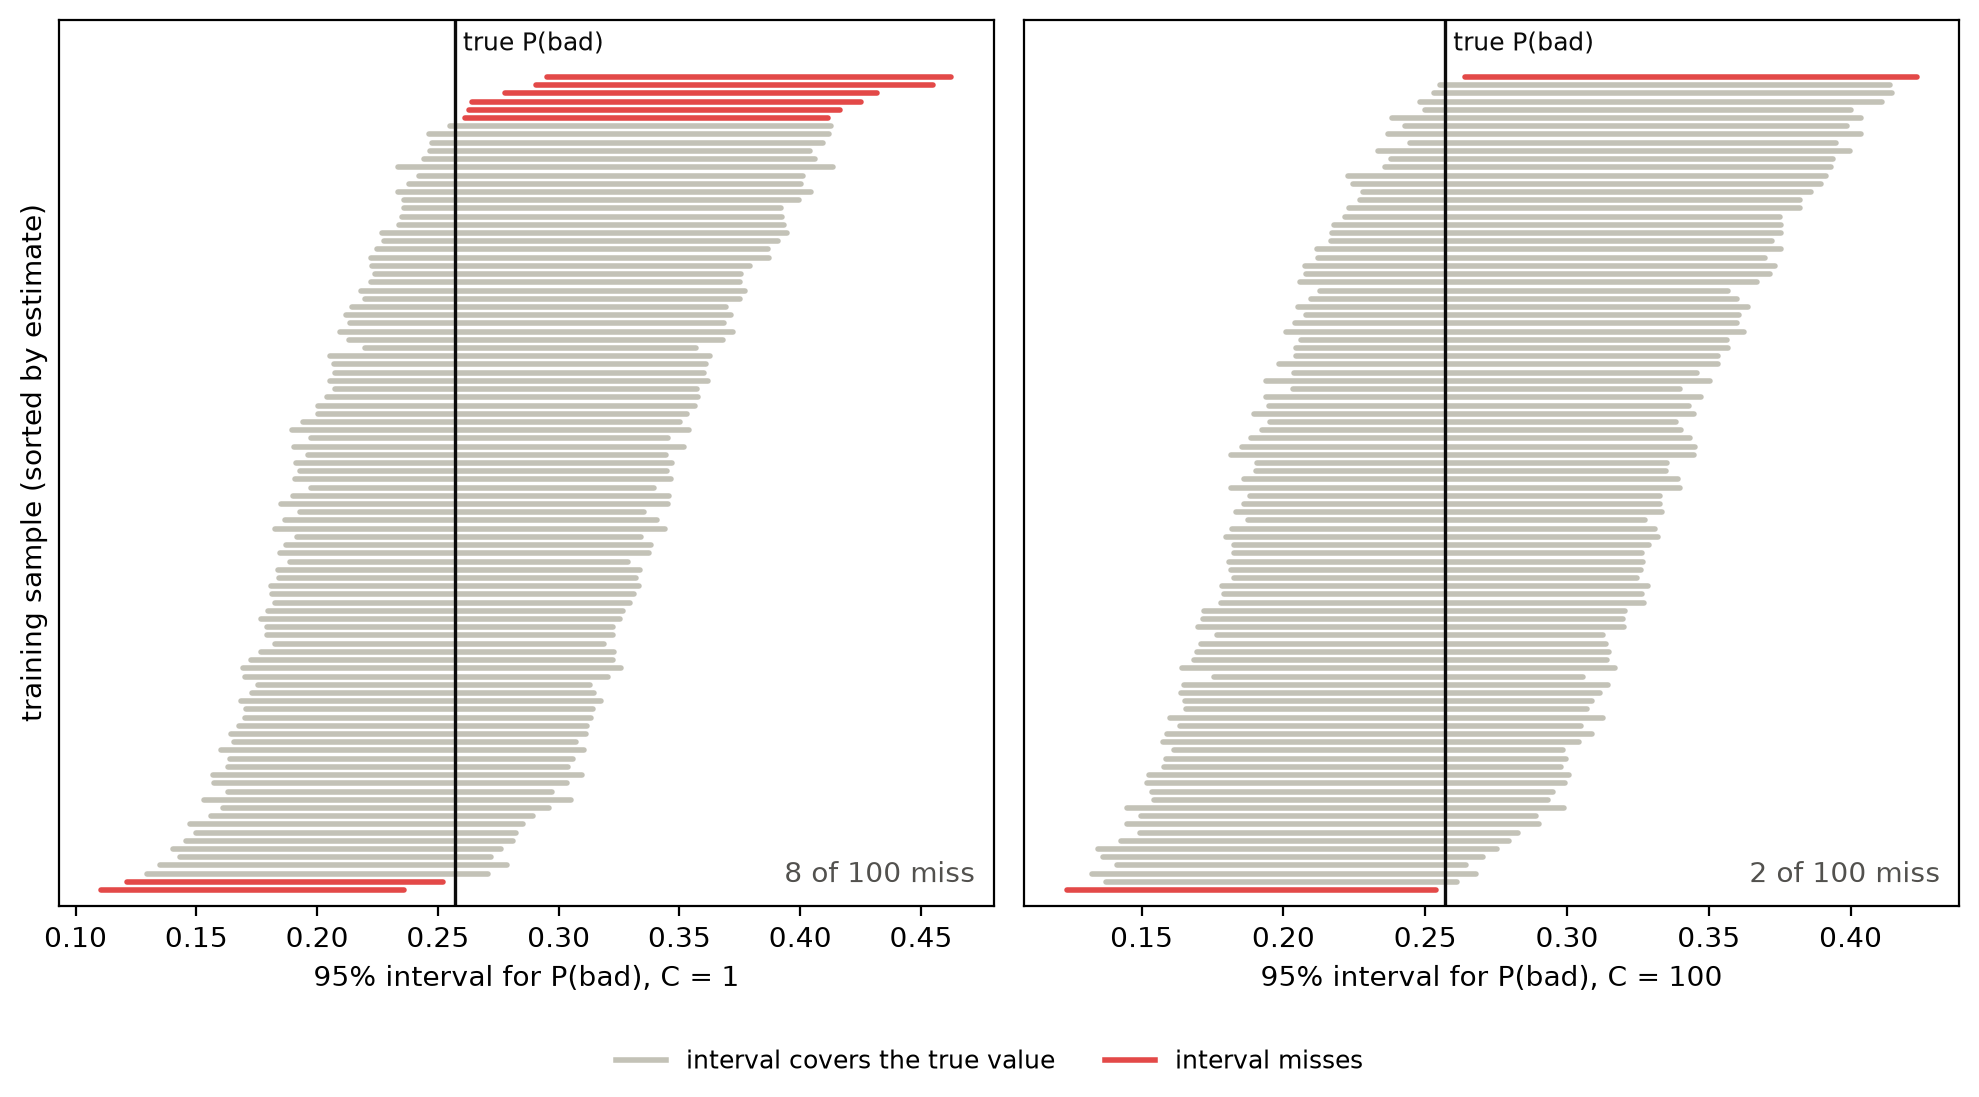

In [14]:
from matplotlib import pyplot as plt

COVERS, MISSES = "#c3c2b7", "#e34948"  # context gray, misses highlighted

who_profile = profiles.index[(profiles[list(EXAMPLE)] == pd.Series(EXAMPLE)).all(axis=1)][0]
shown = 100
fig, axes = plt.subplots(1, 2, figsize=(10, 5.5), sharey=True)
for ax, (c, ci) in zip(axes, sim.items()):
    lo_hi = ci[:shown, who_profile]
    order_ = np.argsort(lo_hi.mean(1))
    hit = (lo_hi[:, 0] <= true_p[who_profile]) & (true_p[who_profile] <= lo_hi[:, 1])
    for row, k in enumerate(order_):
        color = COVERS if hit[k] else MISSES
        ax.plot(lo_hi[k], [row, row], color=color, lw=2, solid_capstyle="round")
    ax.axvline(true_p[who_profile], color="#0b0b0b", lw=1.2)
    ax.text(
        true_p[who_profile], shown + 1.5, " true P(bad)", color="#0b0b0b", va="bottom", fontsize=9
    )
    ax.set_xlabel(f"95% interval for P(bad), C = {c:g}")
    ax.text(
        0.98,
        0.02,
        f"{(~hit).sum()} of {shown} miss",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        color="#52514e",
        fontsize=10,
    )
    ax.set_ylim(-2, shown + 6)
axes[0].set_ylabel("training sample (sorted by estimate)")
axes[0].set_yticks([])
handles = [
    plt.Line2D([], [], color=COVERS, lw=2, label="interval covers the true value"),
    plt.Line2D([], [], color=MISSES, lw=2, label="interval misses"),
]
fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False, fontsize=9)
fig.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

### Coverage across all 18 profiles

The share of samples whose interval covers the truth, per profile. With 200 samples, a correctly calibrated 95% interval lands inside the gray band about 95% of the time.


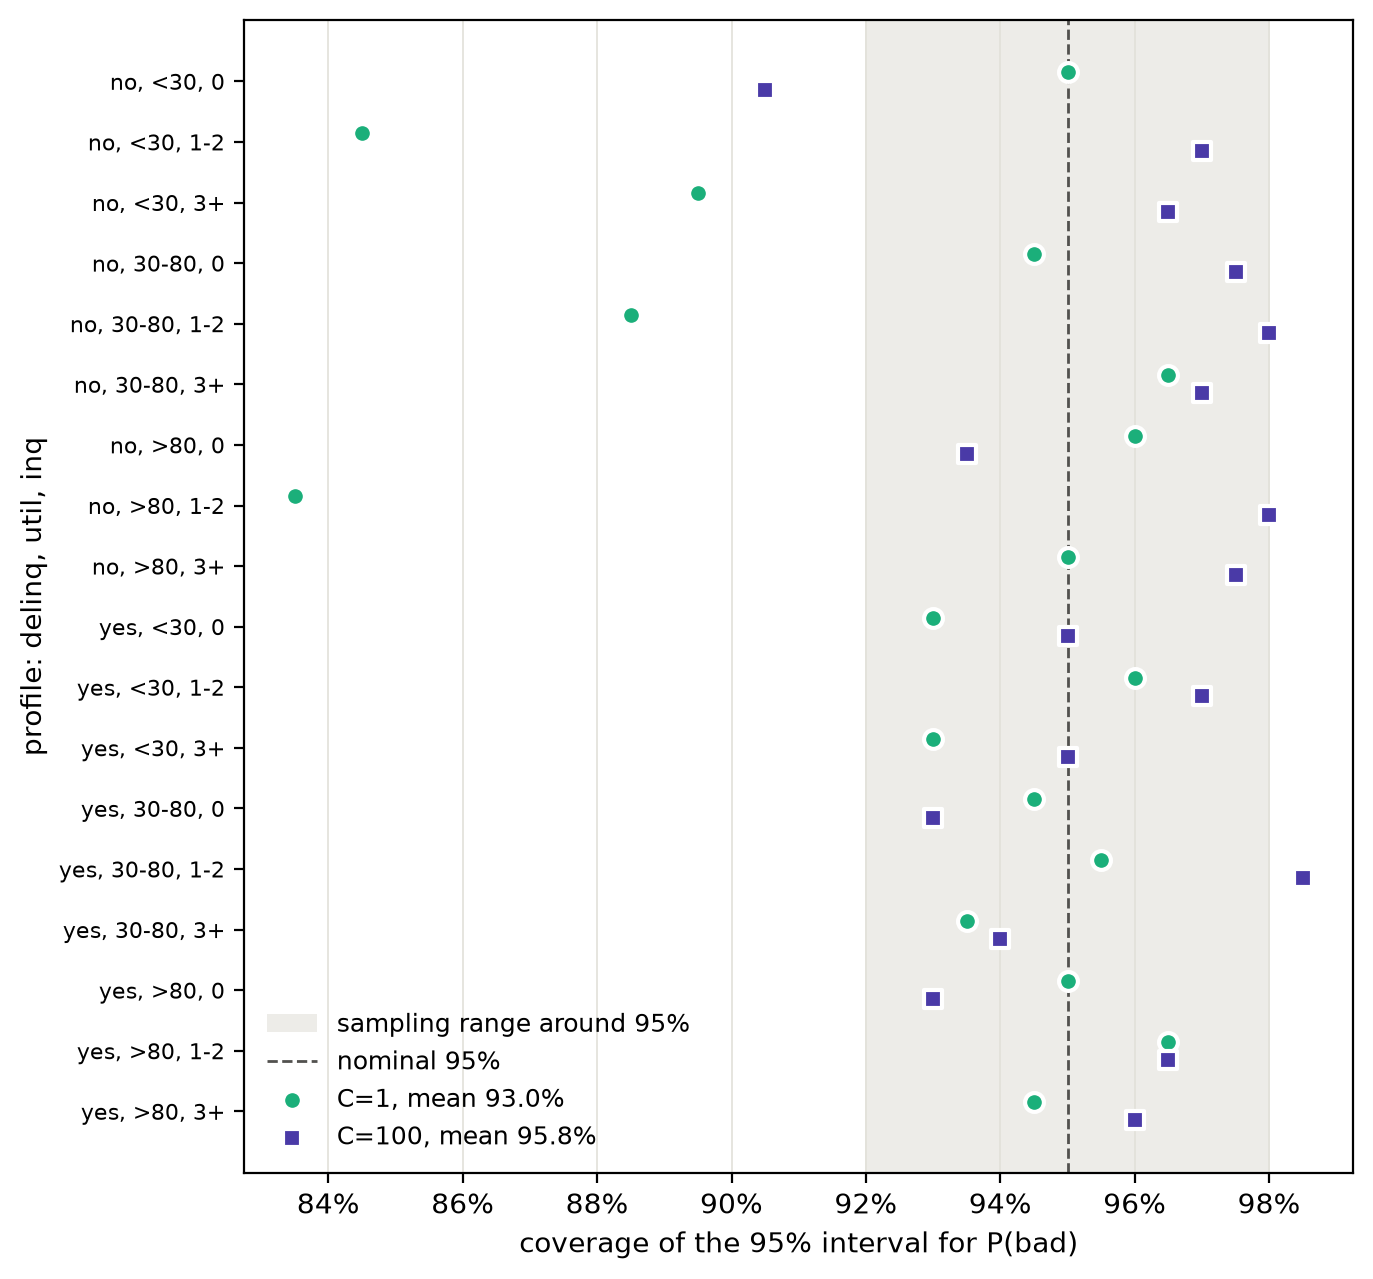

In [15]:
band = 1.96 * np.sqrt(0.95 * 0.05 / REPS)
SERIES = {f"C={C:g}": ("#1baf7a", "o"), "C=100": ("#4a3aa7", "s")}
fig, ax = plt.subplots(figsize=(7, 6.5))
rows = np.arange(len(coverage))
ax.axvspan(
    0.95 - band, 0.95 + band, color="#e1e0d9", alpha=0.6, lw=0, label="sampling range around 95%"
)
ax.axvline(0.95, color="#52514e", lw=1, ls="--", label="nominal 95%")
for (name, (color, marker)), offset in zip(SERIES.items(), (-0.15, 0.15)):
    ax.scatter(
        coverage[name],
        rows + offset,
        color=color,
        marker=marker,
        s=46,
        edgecolor="white",
        linewidth=1.5,
        zorder=3,
        label=f"{name}, mean {coverage[name].mean():.1%}",
    )
ax.set_yticks(rows, coverage.index, fontsize=8)
ax.set_ylabel(f"profile: {', '.join(ORDER)}")
ax.invert_yaxis()
ax.set_xlabel("coverage of the 95% interval for P(bad)")
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0, decimals=0))
ax.grid(axis="x", color="#e1e0d9", lw=0.6)
ax.set_axisbelow(True)
ax.legend(loc="lower left", frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

(Numbers for the default `ORDER`.) With the penalty almost off (C = 100) the intervals cover the truth at close to the nominal 95% rate; one profile of 18 sits just below the gray band, about what chance gives with 18 profiles. At the notebook's C = 1 coverage drops, and only on a few profiles: those with `delinq=no` and one or more inquiries, where bads are scarce. There the penalty pulls the estimate about one standard deviation toward marginal WOE; across profiles, lower coverage goes with larger bias (correlation −0.93). The standard error does its job (it slightly overstates the spread there), but the interval measures sampling noise, not the penalty's bias. With a strong penalty, read it as an interval under the model's assumptions.
